In [1]:
import json
import numpy as np
from openai import OpenAI, AsyncOpenAI
import openai
from collections import defaultdict
import pytrec_eval
from string import Template
import random
print(openai.__version__)
client = AsyncOpenAI(
    api_key=snowflake_key,
    base_url=snowflake_base_url
)

random.seed(0)

1.90.0


In [2]:
import sys
sys.path.append('./..')
from prompts.all_prompts import *
from order_by.sorting import *
from order_by.utils import *
from order_by.optimizer import *
from order_by.pointwise import *


In [3]:
from dataclasses import dataclass
from tqdm import tqdm
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

@dataclass
class Passage:
    passageid: str
    text: str

In [4]:
class SafeDict(dict):
    def __missing__(self, k):  # leave untouched
        return '{' + k + '}'

In [5]:
map_key_2_criteria = {'irony':'irony', 'hate': 'hateful', 'sentiment':'positive', 'offensive':'offensive'}
criteria_2_key = {'irony':'irony', 'hateful': 'hate', 'positive':'sentiment', 'offensive':'offensive'}
def load_run_file(path, sample_ratio = None):
    map_key_2_criteria = {'irony':'irony', 'hate': 'hateful', 'sentiment':'positive', 'offensive':'offensive'}
    random.seed(0)
    first_stage_rankings = []
    id_to_list = defaultdict(list)
    label_by_id = defaultdict(dict)
    
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    if sample_ratio is not None:
        for k in data.keys():
            texts = data[k]["text"]
            labels = data[k]["label"]

            n = len(texts)
            sample_size = max(1, int(n * sample_ratio))

            indices = random.sample(range(n), sample_size)
            data[k]["text"] = [texts[i] for i in indices]
            data[k]["label"] = [labels[i] for i in indices]
            
    print(data.keys())
    i = 0
    for key, d in data.items():
        print(key)
        criteria = map_key_2_criteria[key]
        text_id = 0
        for text, label in zip(d['text'], d['label']):
            id_to_list[str(i)].append(Passage(passageid=str(text_id), text=text))
            label_by_id[str(i)][str(text_id)] = int(label)            
            text_id += 1
        i += 1
            
    for index, key in enumerate(data.keys()):
        criteria = map_key_2_criteria[key]
        passages = id_to_list[str(index)]
        first_stage_rankings.append(( criteria, passages))
        
    return first_stage_rankings, label_by_id

In [6]:
tweetEval_file = '../data/tweetEval.json'
first_stage_candidates, gold = load_run_file(tweetEval_file)

evaluator = pytrec_eval.RelevanceEvaluator(gold, {'ndcg_cut.10'})

dict_keys(['irony', 'hate', 'sentiment', 'offensive'])
irony
hate
sentiment
offensive


In [7]:
print(gold.keys())

dict_keys(['0', '1', '2', '3'])


In [8]:
print(len(first_stage_candidates))
print(len(first_stage_candidates[0]))
arr = [ (_, len(c) )for _, c in first_stage_candidates]
print(arr)

4
2
[('irony', 784), ('hateful', 500), ('positive', 500), ('offensive', 860)]


In [9]:
def add_result(results, model, alg, acc, price, token, query_acc, query_alg=None):
    results[model]['alg'].append(alg)
    results[model]['acc'].append(acc)
    results[model]['price'].append(price)
    results[model]['token'].append(token)
    results[model]['query_acc'].append(query_acc)
    if query_alg:
        results[model]['query_alg'].append(query_alg)
        assert abs(acc - sum(query_acc)/len(query_acc)) < 0.1
results = {}
optimizer_results = {}

for modelname in ["llama3.1-70b", 'llama3.1-405b']:
    results[modelname] = {'alg':[], 'price':[], 'token':[], 'acc':[], 'query_acc':[]}
    optimizer_results[modelname] = {'alg':[], 'price':[], 'token':[], 'acc':[], 'query_acc':[], 'query_alg':[]}

BATCH_SIZE = 5
def chunk_list(data, size):
    for i in range(0, len(data), size):
        yield data[i : i + size]

In [10]:
# Optimizer

In [18]:
optimizer_results = {}

for modelname in ["llama3.1-70b", 'llama3.1-405b']:
    optimizer_results[modelname] = {'alg':[], 'price':[], 'token':[], 'acc':[], 'query_acc':[], 'query_alg':[]}

    
for modelname, budget, proxy_policy in [("llama3.1-70b", 15, 'borda'), ("llama3.1-70b", 15, 'llm_judge'), 
                                        ("llama3.1-405b", 30, 'borda'), ("llama3.1-405b", 30, 'llm_judge'), ]:
    print(modelname, budget, proxy_policy)
    run = {}
    total_input_tokens, total_output_tokens = 0, 0
    tasks = []
    budget = budget / len(first_stage_candidates)
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        llm_judge_prompt_template = llm_judge_prompt.format_map(SafeDict(criteria=f"The top-10 texts that exhibit the highest degree of {criteria}!"))
        
        pointwise_prompt_template = tweetEval_pointwise_prompt_template.format_map(SafeDict(criteria=criteria))
        external_pointwise_prompt_template = tweetEval_external_pointwise_prompt_template.format_map(SafeDict(criteria=criteria))
        external_comparison_prompt_template = tweetEval_external_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
        pairwise_comparison_prompt_template = tweetEval_pairwise_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
        
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
        # sample_size = int(0.1 * len(passage_list))
        sample_size = 20
        print('sample_size', sample_size)
        
        optimizer = OrderByOptimizer(client, passage_list[:], 
                                    membership_inference_prompt.format_map(SafeDict(description=f"{criteria} on tweet")),
                                    pointwise_prompt_template,
                                    external_pointwise_prompt_template,
                                    pairwise_comparison_prompt_template,
                                    external_comparison_prompt_template,
                                    budget, modelname, True, llm_judge_prompt_template, proxy_ground_truth_policy = proxy_policy, 
                                    sample_size = sample_size, has_id_and_row = True, 
                                    ideal_oracle = gold[str(i)], k=10, judge_model='llama3.1-405b')
    
        # sorted_data, num_api_calls, in_tokens, out_tokens = await optimizer.physical_order_by_impl()
        coro = optimizer.physical_order_by_impl()
        tasks.append((i, modelname, budget, proxy_policy, coro))
    
    coroutines_to_run = [task_tuple[4] for task_tuple in tasks]
    print('coroutines_to_run', len(coroutines_to_run))
    all_results = []
    
    batches = list(chunk_list(coroutines_to_run, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Optimizer Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)
    query_alg = []
    for task_info, result_data in zip(tasks, all_results):
        qid = task_info[0]
        alg_result, alg_name = result_data
        query_alg.append(alg_name)
        sorted_data, num_api_calls, in_tokens, out_tokens = alg_result
        for data, i in zip( sorted_data, range(len(sorted_data))):
            if len(data) == 2:
                doc_id, text = data
                if str(qid) not in run:
                    run[str(qid)] = {}
                run[str(qid)][str(doc_id)] = float(i+1)
            else:
                if str(qid) not in run:
                    run[str(qid)] = {}
                doc_id, score, _ = data     
                run[str(qid)][str(doc_id)] = float(score)
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
    print('start to evaluate')
    metrics = evaluator.evaluate(run)
    print(proxy_policy)
    for i, m in metrics.items():
        print(i, m['ndcg_cut_10'])
    mean_ndcg = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}-{proxy_policy}-{budget}, Mean nDCG@10:", mean_ndcg)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
        
    add_result(optimizer_results, modelname, f'{proxy_policy},{budget}',\
               mean_ndcg, tokens2price(modelname, total_input_tokens, total_output_tokens), total_input_tokens + total_output_tokens,\
               query_acc, query_alg)
 

llama3.1-70b 15 borda


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 1951.29it/s]


sample_size 20
sample_size 20
sample_size 20
sample_size 20
coroutines_to_run 4

--- Running Optimizer Batch 1/1 ---
membership count: 20
Membership confirmed!
membership count: 20
Membership confirmed!
membership count: 20
Membership confirmed!
membership count: 20
Membership confirmed!
running final decision algorithm point cost 0.050773
alg name point real cost 0.052559 alg cost est {} budget 3.75
running final decision algorithm point cost 0.044163
alg name point real cost 0.045702 alg cost est {} budget 3.75
running final decision algorithm point cost 0.077399
alg name point real cost 0.078927 alg cost est {} budget 3.75
running final decision algorithm point cost 0.085715
alg name point real cost 0.087671 alg cost est {} budget 3.75
start to evaluate
borda
0 1.0
1 1.0
2 0.8923085103615065
3 0.9052116356304493
llama3.1-70b-borda-3.75, Mean nDCG@10: 0.949380036497989
tokens: 662147, price: 0.264859
llama3.1-70b 15 llm_judge


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 15155.57it/s]


sample_size 20
sample_size 20
sample_size 20
sample_size 20
coroutines_to_run 4

--- Running Optimizer Batch 1/1 ---
membership count: 20
Membership confirmed!
membership count: 20
Membership confirmed!
membership count: 20
Membership confirmed!
membership count: 20
Membership confirmed!
running final decision algorithm point cost 0.050773
alg name point real cost 0.052559 alg cost est {} budget 3.75
running final decision algorithm point cost 0.044163
alg name point real cost 0.045702 alg cost est {} budget 3.75
running final decision algorithm point cost 0.077399
alg name point real cost 0.078927 alg cost est {} budget 3.75
running final decision algorithm point cost 0.085715
alg name point real cost 0.087671 alg cost est {} budget 3.75
start to evaluate
llm_judge
0 1.0
1 1.0
2 0.8923085103615065
3 0.9052116356304493
llama3.1-70b-llm_judge-3.75, Mean nDCG@10: 0.949380036497989
tokens: 662147, price: 0.264859
llama3.1-405b 30 borda


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 11941.08it/s]

sample_size 20
sample_size 20
sample_size 20
sample_size 20
coroutines_to_run 4

--- Running Optimizer Batch 1/1 ---
membership count: 6
Not in training data!
membership inference cost 0.020372
remaining budget 7.479628
membership count: 2
Not in training data!
membership inference cost 0.02132
remaining budget 7.47868
membership count: 10
Not in training data!
membership inference cost 0.0214
remaining budget 7.4786
membership count: 7
Not in training data!
membership inference cost 0.023532
remaining budget 7.476468
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-405b
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-405b
Final memory size for external pointwise: m = 4 (agreement = 0.62), modelname: llama3.1-405b
Final memory size for external pointwise: m = 16, modelname: llama3.1-405b
invoked budget 0.23727999999999996
remaining budget after initial invocation 7.24132
ext_bubble batch_size: 4
ext_bubble_4

running final decision algorithm ext_merge_4 cost 1.5923
alg name ext_merge_4 real cost 2.13866 alg cost est {'ext_bubble_4': 2.9282999999999997, 'ext_merge_4': 1.3935440000000001, 'quick_3': 9.85018339238981, 'quick': 2.8825089225586416, 'ext_point': 0.730312, 'point': 0.823192} budget 7.061024
running final decision algorithm point cost 0.501936
alg name point real cost 0.89046 alg cost est {'ext_bubble_4': 1.5360999999999998, 'ext_merge_4': 0.6122, 'quick_3': 3.287849259933267, 'quick': 1.3845853900896479, 'ext_point': 0.5556, 'point': 0.4858} budget 7.2038519999999995
running final decision algorithm quick cost 2.663004
alg name quick real cost 3.058064 alg cost est {'ext_bubble_4': 2.2710912, 'ext_merge_4': 0.9723168, 'quick_3': 5.617483380150181, 'quick': 2.0967286199353414, 'ext_point': 0.6494656, 'point': 0.7526399999999999} budget 7.192676
start to evaluate
borda
0 1.0
1 0.9363792118010483
2 0.9350624941733298
3 0.8611375561264454
llama3.1-405b-borda-7.5, Mean nDCG@10: 0.93314

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 14807.78it/s]


sample_size 20
sample_size 20
sample_size 20
sample_size 20
coroutines_to_run 4

--- Running Optimizer Batch 1/1 ---
membership count: 6
Not in training data!
membership inference cost 0.020372
remaining budget 7.479628
membership count: 2
Not in training data!
membership inference cost 0.02132
remaining budget 7.47868
membership count: 10
Not in training data!
membership inference cost 0.0214
remaining budget 7.4786
membership count: 7
Not in training data!
membership inference cost 0.023532
remaining budget 7.476468
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-405b
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-405b
Final memory size for external pointwise: m = 4 (agreement = 0.62), modelname: llama3.1-405b
Final memory size for external pointwise: m = 16, modelname: llama3.1-405b
invoked budget 0.23727999999999996
remaining budget after initial invocation 7.24132
ext_bubble batch_size: 4
ext_bubble_4

# Pointwise experiments

In [13]:
for modelname in ["llama3.1-70b", 'llama3.1-405b']:
    tasks = []
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
            
        pointwise_prompt_template = tweetEval_pointwise_prompt_template.format_map(SafeDict(criteria=criteria))
        coro = pointwise_sort(passage_list[:], client, pointwise_prompt_template, modelname, float, PointwiseRelevanceKey)
        tasks.append((i, modelname, 'point', coro))
    
    print(f"\nRunning {len(tasks)} tasks for {modelname} in parallel...")
    
    coroutines_to_run = [task_tuple[3] for task_tuple in tasks]
    all_results = []
    
    # Split the coroutines into batches of 10
    batches = list(chunk_list(coroutines_to_run, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)

    print(f"Tasks for {modelname} complete.")
    
    for task_info, result_data in zip(tasks, all_results):
        qid = task_info[0] 
        sorted_data, scores, num_api_calls, in_tokens, out_tokens = result_data 
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens

    metrics = evaluator.evaluate(run)
    for i, metric in metrics.items():
        print(i, metric['ndcg_cut_10'])
    mean_pointwise = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, pointwise Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
            
    add_result(results, modelname, 'point', mean_pointwise, tokens2price(modelname, total_input_tokens, total_output_tokens), total_input_tokens + total_output_tokens, query_acc)
    
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    tasks_to_run = []
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
        external_pointwise_prompt_template = tweetEval_external_pointwise_prompt_template.format_map(SafeDict(criteria=criteria))
        coro = external_pointwise_sort(
            passage_list[:], 
            external_values, 
            client, 
            external_pointwise_prompt_template,
            modelname, 
            float, 
            0.1, 
            isPassage=True, 
            max_m=16
        )
        tasks_to_run.append((i, coro))
        
    print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
    coroutines = [task[1] for task in tasks_to_run]
    all_results = []
    batches = list(chunk_list(coroutines, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)

    for task_info, result_data in zip(tasks_to_run, all_results):
        qid = task_info[0]
        sorted_data, scores, num_api_calls, in_tokens, out_tokens, _ = result_data
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
    
    metrics = evaluator.evaluate(run)
    for i, m in metrics.items():
        print(i, m['ndcg_cut_10'])
    mean_external_pointwise = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, external pointwise Mean nDCG@10:", mean_external_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
        
    add_result(
        results, 
        modelname, 
        'ext_point', 
        mean_external_pointwise,
        tokens2price(modelname, total_input_tokens, total_output_tokens), 
        total_input_tokens + total_output_tokens,
        query_acc
    )

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 8656.97it/s]



Running 4 tasks for llama3.1-70b in parallel...

--- Running Batch 1/1 ---
Tasks for llama3.1-70b complete.
0 1.0
1 1.0
2 0.8923085103615065
3 0.9052116356304493
llama3.1-70b, pointwise Mean nDCG@10: 0.949380036497989
tokens: 645125, price: 0.25805


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 13210.41it/s]



Running 4 tasks in parallel...

--- Running Batch 1/1 ---
Final memory size for external pointwise: m = 4 (agreement = 0.25), modelname: llama3.1-70b
Final memory size for external pointwise: m = 4 (agreement = 0.62), modelname: llama3.1-70b
Final memory size for external pointwise: m = 16, modelname: llama3.1-70b
Final memory size for external pointwise: m = 16, modelname: llama3.1-70b
0 0.7948833326720564
1 0.933745776545611
2 0.754236908846201
3 0.914856882358379
llama3.1-70b, external pointwise Mean nDCG@10: 0.8494307251055618
tokens: 229915, price: 0.091966


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 23140.99it/s]



Running 4 tasks for llama3.1-405b in parallel...

--- Running Batch 1/1 ---
Tasks for llama3.1-405b complete.
0 0.9216017310213247
1 0.9363792118010483
2 0.9350624941733298
3 1.0
llama3.1-405b, pointwise Mean nDCG@10: 0.9482608592489257
tokens: 630480, price: 2.52192


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 13508.23it/s]


Running 4 tasks in parallel...

--- Running Batch 1/1 ---
Final memory size for external pointwise: m = 2 (agreement = 0.25), modelname: llama3.1-405b
Final memory size for external pointwise: m = 2 (agreement = 0.00), modelname: llama3.1-405b
Final memory size for external pointwise: m = 2 (agreement = 0.25), modelname: llama3.1-405b
Final memory size for external pointwise: m = 8 (agreement = 0.69), modelname: llama3.1-405b
0 0.9052116356304493
1 0.6563033086078546
2 0.9334739949321357
3 0.5988751049740155
llama3.1-405b, external pointwise Mean nDCG@10: 0.7734660110361138
tokens: 396846, price: 1.587384


# Pairwise experiments

In [14]:
print('start')

start


In [15]:
for modelname in ["llama3.1-70b", 'llama3.1-405b']:
    memory = [4]
    for m in memory:
        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        tasks_to_run = []
        for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
            passage_list = []
            for r in ranking:
                passage_list.append( (r.passageid, r.text) ) 

            external_comparison_prompt_template = tweetEval_external_comparison_prompt_template.format_map(SafeDict(criteria=criteria))

            coro = external_bubble_sort(
                passage_list[:], 
                external_comparisons, 
                m, 
                client, 
                external_comparison_prompt_template, 
                modelname, 
                True,
                False,
                limit_k=10
            )
            tasks_to_run.append((i, coro))
            
        print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
        coroutines = [task[1] for task in tasks_to_run]
        all_results = []
        batches = list(chunk_list(coroutines, BATCH_SIZE))
        for i, batch in enumerate(batches):
            print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
            batch_results = await asyncio.gather(*batch)
            all_results.extend(batch_results)
        print("All tasks complete.")

        for task_info, result_data in zip(tasks_to_run, all_results):
            qid = task_info[0]
            sorted_data, num_api_calls, in_tokens, out_tokens = result_data
            run[str(qid)] = {
                str(doc_id): float(i+1)
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
            
        metrics = evaluator.evaluate(run)
        mean_bubble = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
        print(f"{modelname}, external_bubble_sort Mean nDCG@10:", mean_bubble)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
        
        query_acc = []
        for metric in metrics.values():
            query_acc.append(metric['ndcg_cut_10'])
        add_result(results, modelname, f'ext_bubble_{m}', mean_bubble, tokens2price(modelname, total_input_tokens, total_output_tokens), total_input_tokens + total_output_tokens, query_acc)

        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        
        tasks_to_run = []
        print(f"Creating {len(first_stage_candidates)} tasks...")
        for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
            passage_list = []
            for r in ranking:
                passage_list.append( (r.passageid, r.text) ) 

            external_comparison_prompt_template = tweetEval_external_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
            coro = external_merge_sort(
                passage_list[:], 
                external_comparisons, 
                m, 
                client, 
                external_comparison_prompt_template, 
                modelname, 
                True,
                False,
                limit_k=10
            )
            
            tasks_to_run.append((i, coro))
        
        print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
        coroutines = [task[1] for task in tasks_to_run]
        all_results = []
        batches = list(chunk_list(coroutines, BATCH_SIZE))
        for i, batch in enumerate(batches):
            print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
            batch_results = await asyncio.gather(*batch)
            all_results.extend(batch_results)
        print("All tasks complete.")
    
        for task_info, result_data in zip(tasks_to_run, all_results):
            qid = task_info[0]
            sorted_data, num_api_calls, in_tokens, out_tokens = result_data
            run[str(qid)] = {
                str(doc_id): float(i+1)
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
    
    
        metrics = evaluator.evaluate(run)
        mean_merge = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
        print(f"{modelname}, external_merge_sort Mean nDCG@10:", mean_merge)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
        query_acc = []
        for metric in metrics.values():
            query_acc.append(metric['ndcg_cut_10'])
        add_result(results, modelname, f'ext_merge_{m}', mean_merge, tokens2price(modelname, total_input_tokens, total_output_tokens), total_input_tokens + total_output_tokens, query_acc)
        

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 18935.91it/s]


Running 4 tasks in parallel...

--- Running Batch 1/1 ---


All tasks complete.
llama3.1-70b, external_bubble_sort Mean nDCG@10: 0.6780948477531322
tokens: 2821776, price: 1.12871
Creating 4 tasks...


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 11522.81it/s]



Running 4 tasks in parallel...

--- Running Batch 1/1 ---
All tasks complete.
llama3.1-70b, external_merge_sort Mean nDCG@10: 0.84476984688367
tokens: 1172736, price: 0.469094


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 21263.90it/s]


Running 4 tasks in parallel...

--- Running Batch 1/1 ---


All tasks complete.
llama3.1-405b, external_bubble_sort Mean nDCG@10: 0.8524682553079574
tokens: 2756000, price: 11.024
Creating 4 tasks...


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 12201.61it/s]


Running 4 tasks in parallel...

--- Running Batch 1/1 ---
All tasks complete.
llama3.1-405b, external_merge_sort Mean nDCG@10: 0.9487208331680141
tokens: 1082841, price: 4.331364


In [16]:
for modelname in ["llama3.1-70b", 'llama3.1-405b']:
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    tasks_to_run = []
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
            
        pairwise_comparison_prompt_template = tweetEval_pairwise_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
        vote = 1
        coro = quick_sort(
            passage_list[:], 
            client, 
            pairwise_comparison_prompt_template, 
            modelname, 
            True, 
            vote, 
            limit_k=10
        )
        tasks_to_run.append((i, coro))

    print(f"\nRunning {len(tasks_to_run)} tasks for {modelname} in parallel...")
    coroutines = [task[1] for task in tasks_to_run]
    all_results = []
    batches = list(chunk_list(coroutines, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)
    print(f"Tasks for {modelname} complete.")

    for task_info, result_data in zip(tasks_to_run, all_results):
        qid = task_info[0]
        sorted_data, num_api_calls, in_tokens, out_tokens = result_data
        run[str(qid)] = {
            str(doc_id): float(i+1)
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
    
    metrics = evaluator.evaluate(run)
    mean_quick = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort Mean nDCG@10:", mean_quick)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
   
    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
    add_result(results, modelname, 'quick', mean_quick, tokens2price(modelname, total_input_tokens, total_output_tokens), total_input_tokens + total_output_tokens, query_acc)

    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    tasks_to_run = []
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
            
        pairwise_comparison_prompt_template = tweetEval_pairwise_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
        vote = 3
        coro = quick_sort(
            passage_list[:], 
            client, 
            pairwise_comparison_prompt_template, 
            modelname, 
            True, 
            vote, 
            limit_k=10
        )    
        # Store the qid and the coroutine to run
        tasks_to_run.append((i, coro))
    
    print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
    coroutines = [task[1] for task in tasks_to_run]
    
    all_results = []
    batches = list(chunk_list(coroutines, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)
    print("All tasks complete.")
    
    for task_info, result_data in zip(tasks_to_run, all_results):
        qid = task_info[0]
        sorted_data, num_api_calls, in_tokens, out_tokens = result_data
        run[str(qid)] = {
            str(doc_id): float(i+1)
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens

    metrics = evaluator.evaluate(run)
    mean_quick_3 = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort with vote={vote} Mean nDCG@10:", mean_quick_3)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
    add_result(results, modelname, 'quick_3', mean_quick_3, tokens2price(modelname, total_input_tokens, total_output_tokens), total_input_tokens + total_output_tokens, query_acc)
        

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 20410.24it/s]



Running 4 tasks for llama3.1-70b in parallel...

--- Running Batch 1/1 ---
Tasks for llama3.1-70b complete.
llama3.1-70b, quick_sort Mean nDCG@10: 0.7809797012750643
tokens: 1970663, price: 0.788265


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 18957.31it/s]


Running 4 tasks in parallel...

--- Running Batch 1/1 ---


All tasks complete.
llama3.1-70b, quick_sort with vote=3 Mean nDCG@10: 0.8398361540657711
tokens: 5261658, price: 2.104663


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 17313.95it/s]



Running 4 tasks for llama3.1-405b in parallel...

--- Running Batch 1/1 ---
Tasks for llama3.1-405b complete.
llama3.1-405b, quick_sort Mean nDCG@10: 0.8554372538335707
tokens: 1857236, price: 7.428944


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 19152.07it/s]


Running 4 tasks in parallel...

--- Running Batch 1/1 ---


All tasks complete.
llama3.1-405b, quick_sort with vote=3 Mean nDCG@10: 0.8698455341958279
tokens: 5374037, price: 21.496148


# Figure

borda 0.949380036497989
judge 0.949380036497989
point [1.0, 1.0, 0.8923085103615065, 0.9052116356304493]
ext_point [0.7948833326720564, 0.933745776545611, 0.754236908846201, 0.914856882358379]
ext_bubble_4 [1.0, 0.5606114592078373, 0.8929581428150791, 0.25880978898961277]
ext_merge_4 [1.0, 0.7162874455029682, 1.0, 0.6627919420317119]
quick [1.0, 0.7788065869851872, 0.8913696435738849, 0.4537425745411855]
quick_3 [1.0, 0.9216017310213247, 0.9276737537834677, 0.5100691314582919]
best choice [',point,ext_bubble_4,ext_merge_4,quick,quick_3', ',point', 'ext_merge_4', 'ext_point'] [1.0, 1.0, 1.0, 0.914856882358379]
['borda,3.75', 'llm_judge,3.75']
optimizer algs:  [['point', 'point', 'point', 'point'], ['point', 'point', 'point', 'point']]
optimizer accuracy:  [[1.0, 1.0, 0.8923085103615065, 0.9052116356304493], [1.0, 1.0, 0.8923085103615065, 0.9052116356304493]]
0.264859 0.949380036497989
0.264859 0.949380036497989


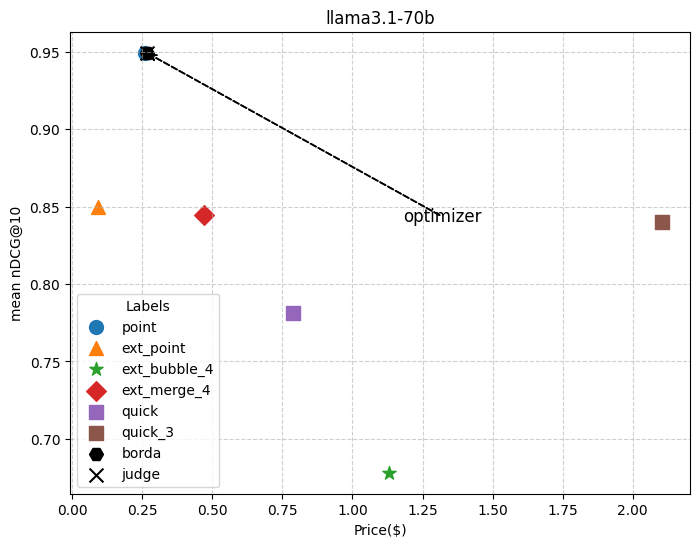

borda 0.9331448155252058
judge 0.9593813969467173
point [0.9216017310213247, 0.9363792118010483, 0.9350624941733298, 1.0]
ext_point [0.9052116356304493, 0.6563033086078546, 0.9334739949321357, 0.5988751049740155]
ext_bubble_4 [1.0, 0.7682269253321375, 0.9350624941733298, 0.7065836017263629]
ext_merge_4 [1.0, 0.933745776545611, 1.0, 0.8611375561264454]
quick [1.0, 0.866947989864271, 1.0, 0.5548010254700116]
quick_3 [0.9363792118010483, 0.9216017310213247, 1.0, 0.6214011939609386]
best choice ['ext_bubble_4,ext_merge_4,quick', ',point', 'ext_merge_4,quick,quick_3', ',point'] [1.0, 0.9363792118010483, 1.0, 1.0]
['borda,7.5', 'llm_judge,7.5']
optimizer algs:  [['quick', 'point', 'ext_bubble_4', 'ext_merge_4'], ['ext_bubble_4', 'quick_3', 'ext_point', 'point']]
optimizer accuracy:  [[1.0, 0.9363792118010483, 0.9350624941733298, 0.8611375561264454], [1.0, 0.9216017310213247, 0.9159238567655447, 1.0]]
8.296704 0.9331448155252058
11.179972 0.9593813969467173


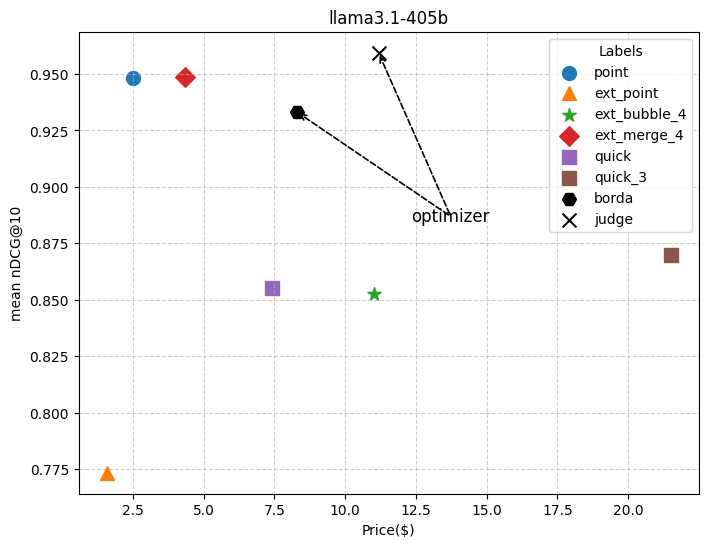

In [22]:
from scipy.optimize import curve_fit

for modelname in results.keys():

    alg2marker = {
        'point': 'o',
        'ext_point': '^',
        'quick': 's',
        'ext_bubble': '*',
        'ext_merge': 'D',
        'borda': 'H',
        'judge': 'x',
        'oracle': 'P', 
        'bt':'P',
    }
    
    kendalltau = results[modelname]['acc']
    tokens = results[modelname]['token']
    prices = results[modelname]['price']
    dot_labels = results[modelname]['alg']
    markers = []
    for alg in dot_labels:
        if alg[-1].isdigit():
            alg = '_'.join(alg.split('_')[:-1])
        markers.append(alg2marker[alg])

    opt_acc = optimizer_results[modelname]['acc']
    opt_prices = optimizer_results[modelname]['price']
    opt_algs = optimizer_results[modelname]['alg']
    opt_algs = [alg.split(',')[0] for alg in opt_algs]
    for i in range(len(opt_algs)):
        if opt_algs[i] == 'llm_judge':
            opt_algs[i] = 'judge'
        elif opt_algs[i] == 'ideal':
            opt_algs[i] = 'oracle'
        print(opt_algs[i], opt_acc[i])
            
    query_acc = results[modelname]['query_acc']
    
    ideal_acc = query_acc[0][:]
    ideal_algs = [''] * len(ideal_acc)
    
    for alg, arr in zip(results[modelname]['alg'], query_acc):
        print(alg, arr)
        for i in range(len(ideal_acc)):
            if arr[i] > ideal_acc[i]:
                ideal_acc[i] = arr[i]
                ideal_algs[i] = alg
            elif arr[i] == ideal_acc[i]:
                ideal_algs[i] += ',' + alg
                
                
    print('best choice', ideal_algs, ideal_acc)
    print(optimizer_results[modelname]['alg'])
    print('optimizer algs: ', optimizer_results[modelname]['query_alg'])
    print('optimizer accuracy: ', optimizer_results[modelname]['query_acc'])

    
    # Create scatter plot
    plt.figure(figsize=(8, 6))
    
    y0 = sum(ideal_acc) / len(ideal_acc)
    # plt.axhline(y=y0, linestyle='--')
    

    for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
        plt.scatter(x, y, s=100, marker=m, label=label)

    for x, y, label in zip(opt_prices, opt_acc, opt_algs):
        m = alg2marker[label]
        plt.scatter(x, y, s=100, marker=m, label=label, color='k')
        print(x,y)

    text_x, text_y = 0.6, 0.6
    ax = plt.gca()
    
    for x, y in zip(opt_prices, opt_acc):
        ax.annotate(
            "",
            xy=(x, y),               # data coordinates (point)
            xycoords="data",
            xytext=(text_x, text_y), # axes fraction coordinates (label position)
            textcoords=ax.transAxes,
            arrowprops=dict(
                arrowstyle="->",
                lw=1.2,
                linestyle="--",
                color = 'k'
            ),
        )
    
    ax.text(
        text_x, text_y,
        "optimizer",
        transform=ax.transAxes,   # <-- IMPORTANT
        fontsize=12,
        ha="center",
        va="center"
    )

    
    plt.legend(title="Labels")

    # Axis labels and title
    plt.xlabel("Price($)")
    plt.ylabel("mean nDCG@10")
    plt.title(f"{modelname}")

    # Add a tick at y0
    yticks = plt.yticks()[0]            # get current tick locations
    # plt.yticks(list(yticks) + [math.floor(y0 * 100) / 100.0])     # add the new tick 
    
    # Show grid and plot
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # plt.savefig(f'{modelname}OptimizerTweetEvalUnlimited.png')

    plt.show()